# Mamba SAE Analysis
state vs delta, layers 12/24/36

このノートは /raid/sasaki/runs/mamba_1.4b_hf 以下に保存された SAE 出力 (state / delta) を横断的に解析するためのテンプレートです。


In [1]:
# 0. 共通セットアップ
import os, json, glob
from pathlib import Path
import math

import torch
import pandas as pd
import matplotlib.pyplot as plt

# 実験パスのルートをここで統一
ROOT = Path('/raid/sasaki/runs/mamba_1.4b_hf')
layers = [12, 24, 36]
signals = ['delta', 'state']
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

def load_meta(layer, signal):
    path = ROOT / f'layer_{layer}' / signal / 'meta.json'
    with open(path) as f:
        return json.load(f)

def load_ckpt(layer, signal):
    path = ROOT / f'layer_{layer}' / signal / 'sae_checkpoint.pt'
    return torch.load(path, map_location=device)

def load_sae(layer, signal):
    # sae_model.SAE を利用 (train_sae.py と同じ構成)
    from sae_model import SAE
    ckpt = load_ckpt(layer, signal)
    sae = SAE(
        input_dim=ckpt['input_dim'],
        hidden_dim=ckpt['hidden_dim'],
        mode=ckpt['mode'],
        l1_lambda=ckpt.get('l1_lambda'),
        k_frac=ckpt.get('k_frac', 0.1),
    ).to(device)
    sae.load_state_dict(ckpt['state_dict'])
    sae.eval()
    return sae, ckpt

def iter_chunks(layer, signal, max_chunks=None):
    pattern = ROOT / f'layer_{layer}' / signal / 'chunk_*.pt'
    for i, path in enumerate(sorted(glob.glob(str(pattern)))):
        if max_chunks is not None and i >= max_chunks:
            break
        yield i, Path(path), torch.load(path, map_location=device)

print('ROOT =', ROOT)
print('device =', device)


ROOT = /raid/sasaki/runs/mamba_1.4b_hf
device = cuda:0


## 1. 学習ログ: 再構成誤差と疎性の推移
train_log.jsonl を集めて (layer, signal) ごとの最終値と推移を可視化。

In [18]:
def load_train_logs():
    rows = []
    for layer in layers:
        for signal in signals:
            log_path = ROOT / f'layer_{layer}' / signal / 'train_log.jsonl'
            if not log_path.exists():
                continue
            with open(log_path) as f:
                for line in f:
                    rec = json.loads(line)
                    rec['layer'] = layer
                    rec['signal'] = signal
                    rows.append(rec)
    return pd.DataFrame(rows)

df_log = load_train_logs()
df_log.head()


,step,epoch,loss,recon_loss,reg_loss,global_sparsity,layer,signal
0,0,0,1.030767,1.030767,0.0,0.499214,12,delta
1,100,0,0.207548,0.207548,0.0,0.497994,12,delta
2,200,0,0.181465,0.181465,0.0,0.490704,12,delta
3,300,0,0.173609,0.173609,0.0,0.472244,12,delta
4,400,0,0.165627,0.165627,0.0,0.447461,12,delta


In [3]:
# 最終ステップのサマリ
last = df_log.sort_values('step').groupby(['layer','signal']).tail(1)
display(last[['layer','signal','loss','recon_loss','reg_loss','global_sparsity']])


,layer,signal,loss,recon_loss,reg_loss,global_sparsity
1469,36,state,0.007828,0.007828,0.0,0.122561
1224,36,delta,0.058095,0.058095,0.0,0.215862
734,24,delta,0.009171,0.009171,0.0,0.126026
489,12,state,4.616620,4.616620,0.0,0.338590
244,12,delta,0.257770,0.257770,0.0,0.168438
979,24,state,0.014701,0.014701,0.0,0.120091


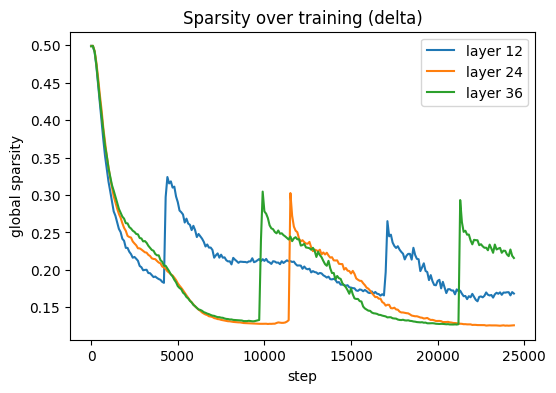

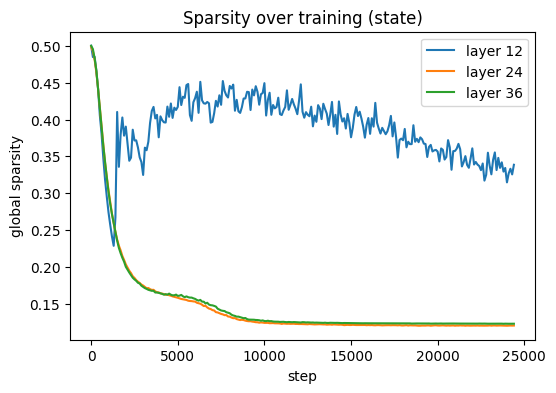

In [4]:
# global_sparsity の推移を signal 別に
for signal in signals:
    plt.figure(figsize=(6,4))
    for layer in layers:
        d = df_log[(df_log.signal==signal) & (df_log.layer==layer)]
        if len(d)==0: continue
        plt.plot(d['step'], d['global_sparsity'], label=f'layer {layer}')
    plt.title(f'Sparsity over training ({signal})')
    plt.xlabel('step')
    plt.ylabel('global sparsity')
    plt.legend()
    plt.show()


## 2. SAE 出力分布（特徴の発火頻度と振幅）
少数チャンクをサンプルして feature ごとの頻度・平均振幅を計算。

In [12]:
import sys, os
sys.path.append("/workspace/")   # ホスト側のルート
# コンテナ内なら "/workspace" など実際のパスに合わせて
def compute_sae_stats(layer, signal, max_chunks=3):
    sae, ckpt = load_sae(layer, signal)
    nonzero = None
    sum_abs = None
    total = 0
    for i, path, x in iter_chunks(layer, signal, max_chunks=max_chunks):
        x = x.to(device)
        with torch.no_grad():
            z = sae.encode(x)[1] if hasattr(sae, 'encode') else sae(x)[1]
        z = z.detach().cpu()
        if nonzero is None:
            nonzero = (z!=0).sum(dim=0)
            sum_abs = z.abs().sum(dim=0)
        else:
            nonzero += (z!=0).sum(dim=0)
            sum_abs += z.abs().sum(dim=0)
        total += z.shape[0]
    freq = nonzero.float() / total
    mean_amp = sum_abs / nonzero.clamp(min=1)
    return freq, mean_amp

stats = {}
for layer in layers:
    for signal in signals:
        freq, mean_amp = compute_sae_stats(layer, signal, max_chunks=3)
        stats[(layer, signal)] = {'freq': freq, 'mean_amp': mean_amp}
        print(f'layer {layer} {signal}: mean freq {float(freq.mean()):.4f}')


/tmp/ipykernel_56/1723842543.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(path, map_location=device)
/tmp/ipykernel_56/1723842543.py:45: FutureWarn

layer 12 delta: mean freq 0.0058
layer 12 state: mean freq 0.0008
layer 24 delta: mean freq 0.1000
layer 24 state: mean freq 0.0985
layer 36 delta: mean freq 0.1000
layer 36 state: mean freq 0.1000


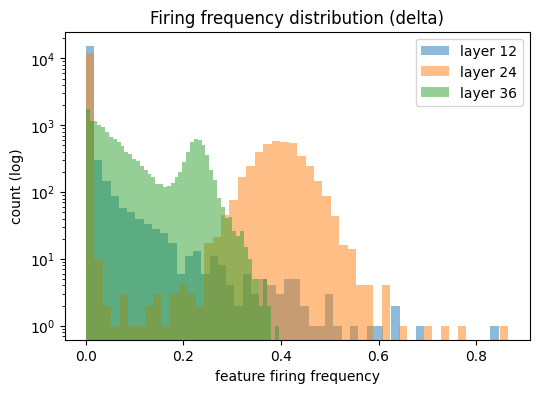

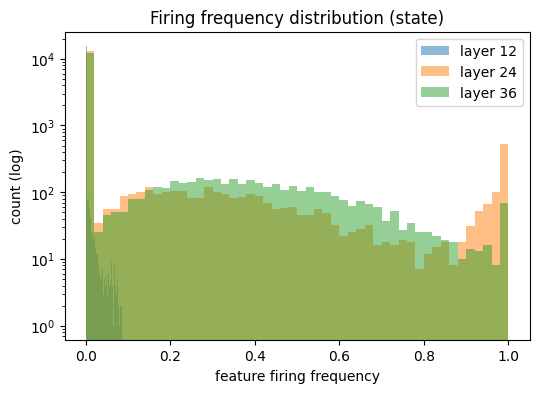

In [13]:
# 発火頻度のヒストグラム（対数軸）
for signal in signals:
    plt.figure(figsize=(6,4))
    for layer in layers:
        freq = stats[(layer, signal)]['freq']
        plt.hist(freq.numpy(), bins=50, alpha=0.5, label=f'layer {layer}')
    plt.yscale('log')
    plt.xlabel('feature firing frequency')
    plt.ylabel('count (log)')
    plt.title(f'Firing frequency distribution ({signal})')
    plt.legend()
    plt.show()


## 3. state vs delta の特徴空間類似度（decoder 行ベクトルのコサイン）

In [14]:
def get_decoder_weight(sae):
    # decoder: Linear(hidden_dim, input_dim) を想定
    W = sae.decoder.weight.detach().cpu()  # [d_out, d_in]
    return W.T  # [d_sae, d_in]

for layer in layers:
    sae_state, _ = load_sae(layer, 'state')
    sae_delta, _ = load_sae(layer, 'delta')
    W_s = get_decoder_weight(sae_state)
    W_d = get_decoder_weight(sae_delta)
    W_s_n = W_s / W_s.norm(dim=1, keepdim=True)
    W_d_n = W_d / W_d.norm(dim=1, keepdim=True)
    sims = W_s_n @ W_d_n.T
    max_s = sims.max(dim=1).values
    max_d = sims.max(dim=0).values
    print(f'Layer {layer}: state->delta mean max cos {float(max_s.mean()):.3f}, delta->state {float(max_d.mean()):.3f}')


/tmp/ipykernel_56/1723842543.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(path, map_location=device)


Layer 12: state->delta mean max cos 0.107, delta->state 0.092
Layer 24: state->delta mean max cos 0.113, delta->state 0.111
Layer 36: state->delta mean max cos 0.132, delta->state 0.128


## 4. 深さ方向の変化 (layer 12→24→36)
発火頻度の平均などを layer に対してプロット。

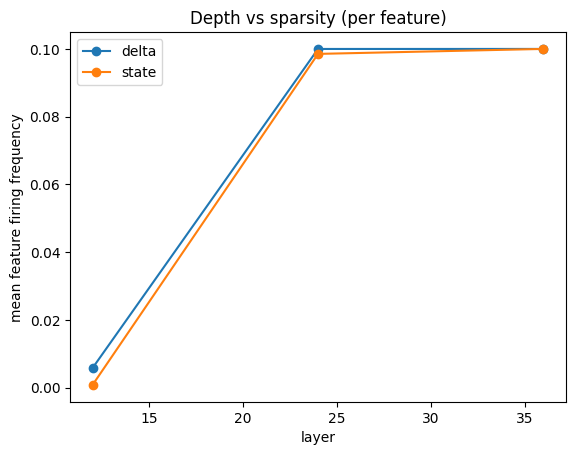

In [15]:
for signal in signals:
    xs, ys = [], []
    for layer in layers:
        freq = stats[(layer, signal)]['freq']
        xs.append(layer)
        ys.append(float(freq.mean()))
    plt.plot(xs, ys, marker='o', label=signal)
plt.xlabel('layer')
plt.ylabel('mean feature firing frequency')
plt.title('Depth vs sparsity (per feature)')
plt.legend()
plt.show()


## 5. 特徴ランキング＆文脈確認のためのスコア
freq と mean_amp から興味深い feature を上位抽出。

In [16]:
def rank_interesting_features(freq, mean_amp, top_k=20):
    score = mean_amp * (freq + 1e-6).pow(-0.5)
    order = torch.argsort(score, descending=True)
    return order[:top_k], score[order[:top_k]]

for layer in layers:
    for signal in signals:
        freq = stats[(layer, signal)]['freq']
        mean_amp = stats[(layer, signal)]['mean_amp']
        idx, score = rank_interesting_features(freq, mean_amp, top_k=10)
        print(f'[layer {layer} | {signal}]')
        for i, s in zip(idx.tolist(), score.tolist()):
            print(f'  feature {i:5d}  score={s:.3f}  freq={freq[i]:.4f}')


[layer 12 | delta]
  feature  2746  score=999.436  freq=0.0000
  feature  9320  score=928.550  freq=0.0000
  feature  9251  score=876.867  freq=0.0000
  feature  7916  score=831.075  freq=0.0000
  feature  8574  score=788.685  freq=0.0000
  feature  6303  score=692.330  freq=0.0000
  feature  9369  score=652.407  freq=0.0000
  feature  1471  score=629.175  freq=0.0000
  feature  4780  score=628.987  freq=0.0000
  feature  6305  score=617.900  freq=0.0000
[layer 12 | state]
  feature    56  score=1826.627  freq=0.0000
  feature   873  score=1568.787  freq=0.0000
  feature 15892  score=1441.935  freq=0.0000
  feature 11711  score=1387.557  freq=0.0000
  feature  2469  score=1326.828  freq=0.0000
  feature  5033  score=1257.666  freq=0.0000
  feature 14262  score=1257.426  freq=0.0000
  feature  6625  score=1222.222  freq=0.0000
  feature  6355  score=1137.747  freq=0.0000
  feature  4875  score=1105.587  freq=0.0000
[layer 24 | delta]
  feature  2354  score=850.706  freq=0.0000
  feature